In [1]:
from qurry import __version__, EntropyMeasure
print("| Using qurrium version:", __version__)

| Using qurrium version: 1.0.0.dev3


/Users/anaball/miniconda3/envs/qurv1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import matplotlib.pyplot as plt
pltparams = {'legend.fontsize': 18,
             'legend.handlelength': 1,
             'xtick.labelsize':18,'ytick.labelsize':18,
             'axes.labelsize':18,
             "text.usetex": True}
plt.rcParams.update(pltparams)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman']
plt.rcParams['text.latex.preamble'] = r'\usepackage{amssymb}'

In [3]:
import json
import numpy as np
from qurry.process.classical_shadow import classical_shadow_complex # >0.14.0 return three dictionay, 0.13 return a single typedict
from custom.projector_rho import custom_mean_rho, MY_METHOD_KEY

In [4]:
def expectation_from_rho(mean_of_rho, operators):
    """Compute Tr(rho @ O) for each operator O using mean_of_rho from ClassicalShadowBasic.

    Args:
        mean_of_rho: basic['mean_of_rho'] where basic = classical_shadow_complex(...)[0]
        operators:   list of numpy arrays, each (2^k x 2^k)

    Returns:
        list of complex128 expectation values
    """
    rho = np.array(mean_of_rho, dtype='complex128')
    return [np.trace(rho @ np.array(op, dtype='complex128')) for op in operators]

In [74]:
from qurry.process.utils.purity.error_mitigation import depolarizing_error_mitgation

In [78]:
dirn=r'../ASQ_data/all_results/'
q0angle=[]
q1angle=[]
qsangle=[]
exps=[]
ideal_q0angle = []
ideal_q1angle = []
ideal_qsangle = []
ideal_exps = []
mitigated_q0angle = []
mitigated_q1angle = []
error_rate_angle = []
X=np.array([[0,1],[1,0]])
Y=np.array([[0,-1.j],[1.j,0]])
I2=np.eye(2)
for angle_step in range(25):

    fn=dirn+'results.angle_{}_of_24.qubits_1_2.circuit_two_cx.json'.format(angle_step)
    print(fn)
    with open(fn, 'r') as file:
        data = json.load(file)
    expcount=[]
    expu=[]
    idealcount=[]
    idealu=[]

    for i in range(90):
        expcount.append(data['results'][i][0])
        expu.append(data['results'][i][1])
        idealcount.append({k: round(v * 32) for k, v in data['ideal_results'][i][0].items()})
        idealu.append(data['ideal_results'][i][1])
    csc0=classical_shadow_complex(shots=32,counts=expcount, random_basis_array=expu,selected_classical_registers=[0],rho_method="single_shots_vectorized")
    csc1=classical_shadow_complex(shots=32,counts=expcount, random_basis_array=expu,selected_classical_registers=[1],rho_method="single_shots_vectorized")
    cscall=classical_shadow_complex(shots=32,counts=expcount, random_basis_array=expu,selected_classical_registers=[0,1],given_operators=[np.kron(X,I2),np.kron(I2,X),np.kron(X,X),np.kron(Y,I2),np.kron(I2,Y),np.kron(Y,Y)],rho_method="single_shots_vectorized")
    p_q0 = csc0[1]['purity']
    p_q1 = csc1[1]['purity']
    p_all = cscall[1]['purity']
    q0angle.append(p_q0)
    q1angle.append(p_q1)
    qsangle.append(p_all)
    exps.append(cscall[2]['estimate_of_given_operators'])
    mit_q0 = depolarizing_error_mitgation(p_q0, p_all, subsystem_size=1, system_size=2)
    mit_q1 = depolarizing_error_mitgation(p_q1, p_all, subsystem_size=1, system_size=2)
    mitigated_q0angle.append(mit_q0['mitigated_purity'])
    mitigated_q1angle.append(mit_q1['mitigated_purity'])
    error_rate_angle.append(mit_q0['error_rate'])  # same for q0 and q1 (depends only on p_all)
    ideal_csc0 = classical_shadow_complex(shots=32, counts=idealcount, random_basis_array=idealu, selected_classical_registers=[0], rho_method="single_shots_vectorized")
    ideal_csc1 = classical_shadow_complex(shots=32, counts=idealcount, random_basis_array=idealu, selected_classical_registers=[1], rho_method="single_shots_vectorized")
    ideal_cscall = classical_shadow_complex(shots=32, counts=idealcount, random_basis_array=idealu, selected_classical_registers=[0, 1], given_operators=[np.kron(X, I2), np.kron(I2, X), np.kron(X, X), np.kron(Y, I2), np.kron(I2, Y), np.kron(Y, Y)], rho_method="single_shots_vectorized")
    ideal_q0angle.append(ideal_csc0[1]['purity'])
    ideal_q1angle.append(ideal_csc1[1]['purity'])
    ideal_qsangle.append(ideal_cscall[1]['purity'])
    ideal_exps.append(ideal_cscall[2]['estimate_of_given_operators'])
exps=np.array(exps)
ideal_exps=np.array(ideal_exps)
mitigated_q0angle = np.array(mitigated_q0angle)
mitigated_q1angle = np.array(mitigated_q1angle)
error_rate_angle  = np.array(error_rate_angle)


../ASQ_data/all_results/results.angle_0_of_24.qubits_1_2.circuit_two_cx.json
../ASQ_data/all_results/results.angle_1_of_24.qubits_1_2.circuit_two_cx.json
../ASQ_data/all_results/results.angle_2_of_24.qubits_1_2.circuit_two_cx.json
../ASQ_data/all_results/results.angle_3_of_24.qubits_1_2.circuit_two_cx.json
../ASQ_data/all_results/results.angle_4_of_24.qubits_1_2.circuit_two_cx.json
../ASQ_data/all_results/results.angle_5_of_24.qubits_1_2.circuit_two_cx.json
../ASQ_data/all_results/results.angle_6_of_24.qubits_1_2.circuit_two_cx.json
../ASQ_data/all_results/results.angle_7_of_24.qubits_1_2.circuit_two_cx.json
../ASQ_data/all_results/results.angle_8_of_24.qubits_1_2.circuit_two_cx.json
../ASQ_data/all_results/results.angle_9_of_24.qubits_1_2.circuit_two_cx.json
../ASQ_data/all_results/results.angle_10_of_24.qubits_1_2.circuit_two_cx.json
../ASQ_data/all_results/results.angle_11_of_24.qubits_1_2.circuit_two_cx.json
../ASQ_data/all_results/results.angle_12_of_24.qubits_1_2.circuit_two_cx.j

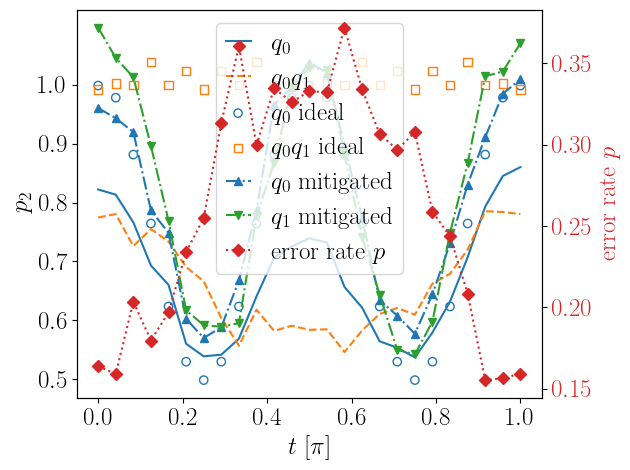

In [79]:

ts = np.arange(0, 25) / 24

fig, ax = plt.subplots()
ax_right = ax.twinx()

ax.plot(ts, q0angle,  label=r'$q_0$',           linestyle='-')
#ax.plot(ts, q1angle, label=r'$q_1$',            linestyle='-')
ax.plot(ts, qsangle,  label=r'$q_0q_1$',         linestyle='--')
ax.scatter(ts, ideal_q0angle,  label=r'$q_0$ ideal',      facecolors='none', edgecolors='C0', marker='o')
#ax.scatter(ts, ideal_q1angle, label=r'$q_1$ ideal',      facecolors='none', edgecolors='C1', marker='x')
ax.scatter(ts, ideal_qsangle,  label=r'$q_0q_1$ ideal',   facecolors='none', edgecolors='C1', marker='s')
ax.plot(ts, mitigated_q0angle, label=r'$q_0$ mitigated',  color='C0', linestyle='-.', marker='^')
ax.plot(ts, mitigated_q1angle, label=r'$q_1$ mitigated',  color='C2', linestyle='-.', marker='v')

ax_right.plot(ts, error_rate_angle, label=r'error rate $p$', color='C3', linestyle=':', marker='D')
ax_right.set_ylabel(r'error rate $p$', color='C3')
ax_right.tick_params(axis='y', labelcolor='C3')

ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_ylabel(r'$p_2$')
ax.set_xlabel(r'$t\ [\pi]$')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_right.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2)
fig.tight_layout()


/Users/anaball/miniconda3/envs/qurv1/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/anaball/miniconda3/envs/qurv1/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/Users/anaball/miniconda3/envs/qurv1/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


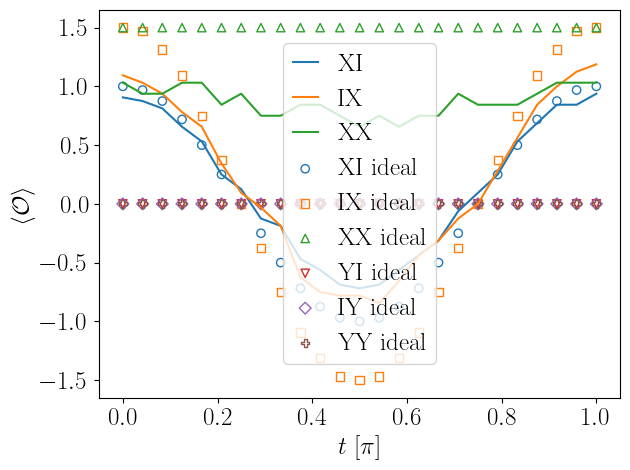

In [77]:
ts = np.arange(0, 25) / 24
plt.cla()
plt.plot(ts, exps[:,0], label='XI')
plt.plot(ts, exps[:,1], label='IX')
plt.plot(ts, exps[:,2], label='XX')
plt.scatter(ts, ideal_exps[:,0], label='XI ideal', facecolors='none', edgecolors='C0', marker='o')
plt.scatter(ts, ideal_exps[:,1], label='IX ideal', facecolors='none', edgecolors='C1', marker='s')
plt.scatter(ts, ideal_exps[:,2], label='XX ideal', facecolors='none', edgecolors='C2', marker='^')
plt.scatter(ts, ideal_exps[:,3], label='YI ideal', facecolors='none', edgecolors='C3', marker='v')
plt.scatter(ts, ideal_exps[:,4], label='IY ideal', facecolors='none', edgecolors='C4', marker='D')
plt.scatter(ts, ideal_exps[:,5], label='YY ideal', facecolors='none', edgecolors='C5', marker='P')

plt.ylabel(r'$\langle \mathcal{O}\rangle$')
plt.xlabel(r'$t\ [\pi]$')
plt.legend()
plt.tight_layout()


In [8]:
# Refactored by Claude (claude-sonnet-4-6) on 2026-04-13
# Reduced redundancy: define given_ops once and wrap csc calls in a helper function

given_ops = [np.kron(X,I2), np.kron(I2,X), np.kron(X,X),
             np.kron(Y,I2), np.kron(I2,Y), np.kron(Y,Y)]

def run_csc(counts, u_array):
    csc0   = classical_shadow_complex(shots=32, counts=counts, random_basis_array=u_array, selected_classical_registers=[0])
    csc1   = classical_shadow_complex(shots=32, counts=counts, random_basis_array=u_array, selected_classical_registers=[1])
    cscall = classical_shadow_complex(shots=32, counts=counts, random_basis_array=u_array, selected_classical_registers=[0,1], given_operators=given_ops)
    return csc0[1]["purity"], csc1[1]["purity"], cscall[1]["purity"], cscall[2]["estimate_of_given_operators"]

q0angle, q1angle, qsangle, exps = [], [], [], []
ideal_q0angle, ideal_q1angle, ideal_qsangle, ideal_exps = [], [], [], []

for angle_step in range(25):
    fn = dirn + "results.angle_{}_of_24.qubits_1_2.circuit_two_cx.json".format(angle_step)
    with open(fn, "r") as file:
        data = json.load(file)

    expcount   = [data["results"][i][0] for i in range(90)]
    expu       = [data["results"][i][1] for i in range(90)]
    idealcount = [{k: round(v * 32) for k, v in data["ideal_results"][i][0].items()} for i in range(90)]
    idealu     = [data["ideal_results"][i][1] for i in range(90)]

    q0a,  q1a,  qsa,  exp_val  = run_csc(expcount,   expu)
    iq0a, iq1a, iqsa, iexp_val = run_csc(idealcount, idealu)

    q0angle.append(q0a);         q1angle.append(q1a);         qsangle.append(qsa);         exps.append(exp_val)
    ideal_q0angle.append(iq0a);  ideal_q1angle.append(iq1a);  ideal_qsangle.append(iqsa);  ideal_exps.append(iexp_val)

exps       = np.array(exps)
ideal_exps = np.array(ideal_exps)


In [9]:
# Computes expectation values of two-qubit Pauli operators (XI, IX, XX, YI, IY, YY)
# from the classical shadow estimated state rho(t), for both experimental and ideal data.
given_ops = [np.kron(X,I2), np.kron(I2,X), np.kron(X,X),
             np.kron(Y,I2), np.kron(I2,Y), np.kron(Y,Y)]
exps_rho = []
ideal_exps_rho = []

for angle_step in range(25):
    fn = dirn + 'results.angle_{}_of_24.qubits_1_2.circuit_two_cx.json'.format(angle_step)
    with open(fn, 'r') as file:
        data = json.load(file)

    expcount   = [data['results'][i][0] for i in range(90)]
    expu       = [data['results'][i][1] for i in range(90)]
    idealcount = [{k: round(v * 32) for k, v in data['ideal_results'][i][0].items()} for i in range(90)]
    idealu     = [data['ideal_results'][i][1] for i in range(90)]

    basic,       _, _ = classical_shadow_complex(shots=32, counts=expcount,   random_basis_array=expu,   selected_classical_registers=[0,1], rho_method='single_shots_vectorized')
    ideal_basic, _, _ = classical_shadow_complex(shots=32, counts=idealcount, random_basis_array=idealu, selected_classical_registers=[0,1], rho_method='single_shots_vectorized')

    exps_rho.append(expectation_from_rho(basic['mean_of_rho'], given_ops))
    ideal_exps_rho.append(expectation_from_rho(ideal_basic['mean_of_rho'], given_ops))

exps_rho       = np.array(exps_rho).real
ideal_exps_rho = np.array(ideal_exps_rho).real

In [10]:
# Computes the linear overlap Tr(rho0 @ rho(t)) between the initial state rho0
# and the shadow-estimated state rho(t) at each angle step, for both experimental and ideal data.
psi = np.ones(2**2, dtype='complex128') / np.sqrt(2**2)
rho0 = np.outer(psi, psi.conj())
linoverlap = []
ideal_linoverlap = []
overlap = []
ideal_overlap = []
rho_c_list = None
ideal_rho_c_list = None

for angle_step in range(25):
    fn = dirn + 'results.angle_{}_of_24.qubits_1_2.circuit_two_cx.json'.format(angle_step)
    with open(fn, 'r') as file:
        data = json.load(file)

    expcount   = [data['results'][i][0] for i in range(90)]
    expu       = [data['results'][i][1] for i in range(90)]
    idealcount = [{k: round(v * 32) for k, v in data['ideal_results'][i][0].items()} for i in range(90)]
    idealu     = [data['ideal_results'][i][1] for i in range(90)]

    basic,       _, _ = classical_shadow_complex(shots=32, counts=expcount,   random_basis_array=expu,   selected_classical_registers=[0,1], rho_method='multi_shots')
    ideal_basic, _, _ = classical_shadow_complex(shots=32, counts=idealcount, random_basis_array=idealu, selected_classical_registers=[0,1], rho_method='multi_shots')

    linoverlap.append(np.trace(rho0 @ np.array(basic['mean_of_rho'], dtype='complex128')))
    ideal_linoverlap.append(np.trace(rho0 @ np.array(ideal_basic['mean_of_rho'], dtype='complex128')))

    proj_t = custom_mean_rho(
        shots=32, counts=expcount, random_basis_array=expu,
        selected_classical_registers=[0, 1], rho_method=MY_METHOD_KEY,
    )
    ideal_proj_t = custom_mean_rho(
        shots=32, counts=idealcount, random_basis_array=idealu,
        selected_classical_registers=[0, 1], rho_method=MY_METHOD_KEY,
    )

    if angle_step == 0:
        proj_c_list       = np.array(proj_t['average_snapshots_rho_list'],       dtype='complex128')
        ideal_proj_c_list = np.array(ideal_proj_t['average_snapshots_rho_list'], dtype='complex128')

    rho_m_list       = np.array(basic['average_snapshots_rho_list'],       dtype='complex128')
    ideal_rho_m_list = np.array(ideal_basic['average_snapshots_rho_list'], dtype='complex128')
    Nu = len(rho_m_list)

    trclusterrho       = np.einsum('nij,nji->n', proj_c_list,       rho_m_list)
    ideal_trclusterrho = np.einsum('nij,nji->n', ideal_proj_c_list, ideal_rho_m_list)
    overlap.append(trclusterrho.sum() / Nu)
    ideal_overlap.append(ideal_trclusterrho.sum() / Nu)

linoverlap       = np.array(linoverlap).real
ideal_linoverlap = np.array(ideal_linoverlap).real
overlap          = np.array(overlap).real
ideal_overlap    = np.array(ideal_overlap).real

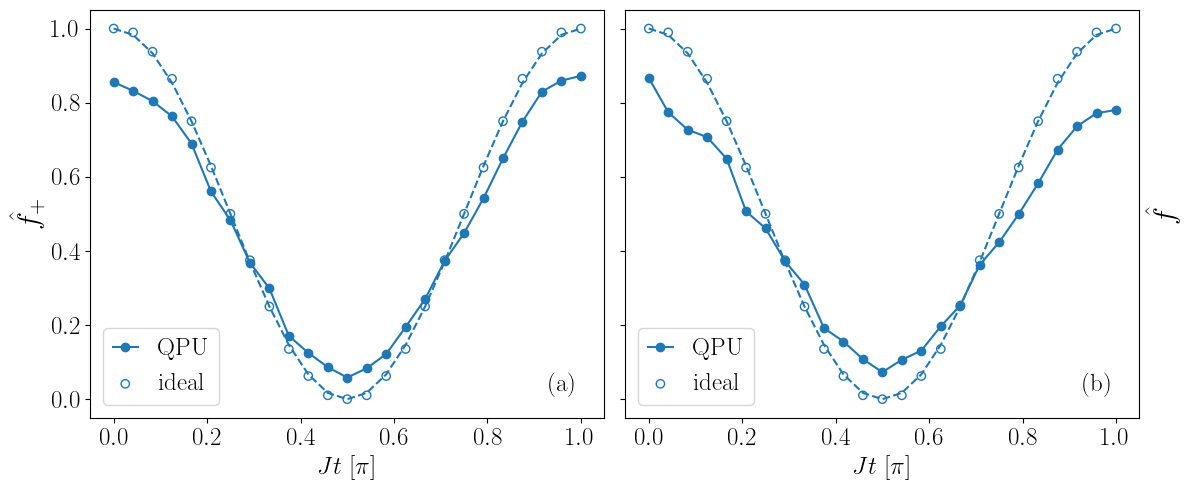

In [69]:
ts = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: linear overlap Tr(rho0 @ rho(t))
ax1.plot(ts, linoverlap,          label=r'QPU',   linestyle='-', marker='o')
ax1.plot(ts, np.cos(ts*np.pi)**2, linestyle='--', color='C0')
ax1.scatter(ts, ideal_linoverlap, label=r'ideal', facecolors='none', edgecolors='C0', marker='o')
ax1.set_xlabel(r'$Jt\ [\pi]$')
ax1.set_ylabel(r'$\hat{f}_{+}$', fontsize=22)
ax1.legend(loc='lower left')
ax1.text(0.95, 0.05, '(a)', transform=ax1.transAxes, ha='right', va='bottom', fontsize=18)

# Right: overlap
ax2.plot(ts, overlap,          label=r'QPU',   linestyle='-', marker='o')
ax2.scatter(ts, ideal_overlap, label=r'ideal', facecolors='none', edgecolors='C0', marker='o')
ax2.plot(ts, np.cos(ts*np.pi)**2, linestyle='--', color='C0')
ax2.set_xlabel(r'$Jt\ [\pi]$')
ax2.set_ylabel(r'$\hat{f}$', fontsize=22)
ax2.yaxis.set_label_position('right')
ax2.legend(loc='lower left')
ax2.text(0.95, 0.05, '(b)', transform=ax2.transAxes, ha='right', va='bottom', fontsize=18)

fig.tight_layout()
plt.savefig('2qIsingoverlap.pdf')
! cp 2qIsingoverlap.pdf ../../qurrium_writing/


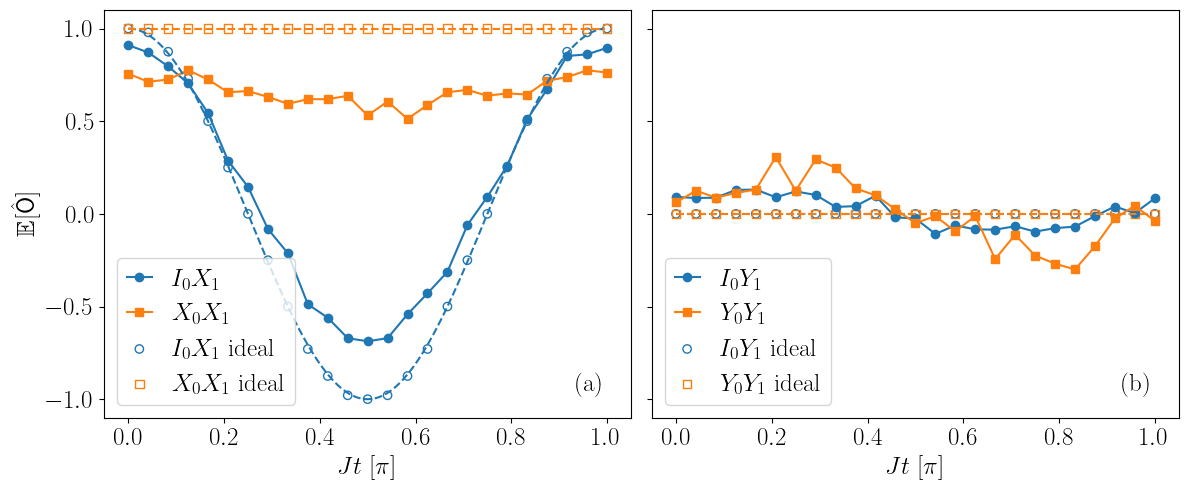

In [70]:
ts = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: X components
ax1.plot(ts, exps_rho[:,0],      label=r'$I_0X_1$', linestyle='-', marker='o')
ax1.plot(ts, exps_rho[:,2],      label=r'$X_0X_1$', linestyle='-', marker='s')
ax1.plot(manyt, np.cos(manyt*np.pi*2), linestyle='--', color='C0')
ax1.plot(manyt,np.ones(manyt.shape), linestyle='--', color='C1')
ax1.scatter(ts, ideal_exps_rho[:,0], label=r'$I_0X_1$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax1.scatter(ts, ideal_exps_rho[:,2], label=r'$X_0X_1$ ideal', facecolors='none', edgecolors='C1', marker='s')
ax1.set_xlabel(r'$Jt\ [\pi]$')
ax1.set_ylabel(r'$\mathbb{E}[\hat{\mathsf{O}}]$')
ax1.legend(loc='lower left')
ax1.text(0.95, 0.05, '(a)', transform=ax1.transAxes, ha='right', va='bottom', fontsize=18)

# Right: Y components
ax2.plot(ts, exps_rho[:,3],      label=r'$I_0Y_1$', linestyle='-', marker='o')
ax2.plot(ts, exps_rho[:,5],      label=r'$Y_0Y_1$', linestyle='-', marker='s')
ax2.plot(manyt,np.zeros(manyt.shape), linestyle='--', color='C0')
ax2.plot(manyt,np.zeros(manyt.shape), linestyle='--', color='C1')
ax2.scatter(ts, ideal_exps_rho[:,3], label=r'$I_0Y_1$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax2.scatter(ts, ideal_exps_rho[:,5], label=r'$Y_0Y_1$ ideal', facecolors='none', edgecolors='C1', marker='s')
ax2.set_xlabel(r'$Jt\ [\pi]$')
ax2.legend(loc='lower left')
ax2.text(0.95, 0.05, '(b)', transform=ax2.transAxes, ha='right', va='bottom', fontsize=18)

fig.tight_layout()
plt.savefig('2qIsingcorr.pdf')
! cp 2qIsingcorr.pdf ../../qurrium_writing/


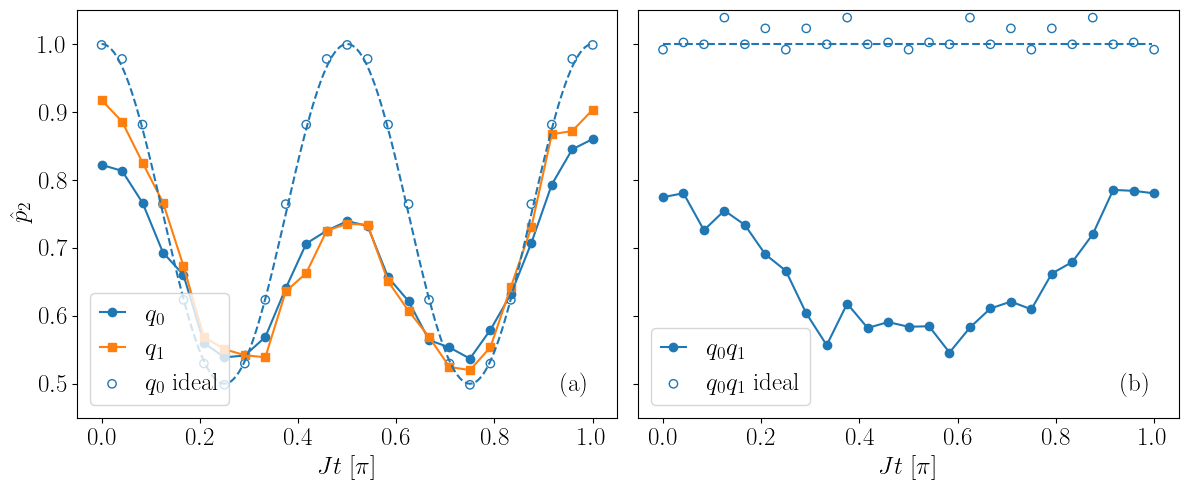

In [102]:
ts = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200
yticks = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: purity of q_0
ax1.plot(ts, q0angle,          label=r'$q_0$',           linestyle='-',  marker='o')
ax1.plot(ts, q1angle,          label=r'$q_1$',           linestyle='-',  marker='s')
ax1.plot(manyt, 1-2*np.sin(manyt*np.pi)**2*np.cos(manyt*np.pi)**2, linestyle='--', color='C0')
ax1.scatter(ts, ideal_q0angle, label=r'$q_0$ ideal',     facecolors='none', edgecolors='C0', marker='o')
#ax1.plot(ts, mitigated_q0angle, label=r'$q_0$ mitigated', color='C2', linestyle='-.', marker='^')
#ax1.plot(ts, mitigated_q1angle, label=r'$q_1$ mitigated', color='C1', linestyle='-.', marker='v')
ax1.set_xlabel(r'$Jt\ [\pi]$')
ax1.set_ylabel(r'$\hat{p}_2$')
ax1.set_ylim(0.45, 1.05)
ax1.set_yticks(yticks)
ax1.legend(loc='lower left')
ax1.text(0.95, 0.05, '(a)', transform=ax1.transAxes, ha='right', va='bottom', fontsize=18)

# Right: purity of q_0 q_1
ax2.plot(ts, qsangle,          label=r'$q_0 q_1$',       linestyle='-', marker='o')
ax2.scatter(ts, ideal_qsangle, label=r'$q_0 q_1$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax2.plot(manyt,np.ones(manyt.shape), linestyle='--', color='C0')
ax2.set_xlabel(r'$Jt\ [\pi]$')
ax2.set_ylim(0.45, 1.05)
ax2.set_yticks(yticks)
ax2.legend(loc='lower left')
ax2.text(0.95, 0.05, '(b)', transform=ax2.transAxes, ha='right', va='bottom', fontsize=18)

fig.tight_layout()
plt.savefig('2qisingpurity.pdf')
! cp 2qisingpurity.pdf ../../qurrium_writing/


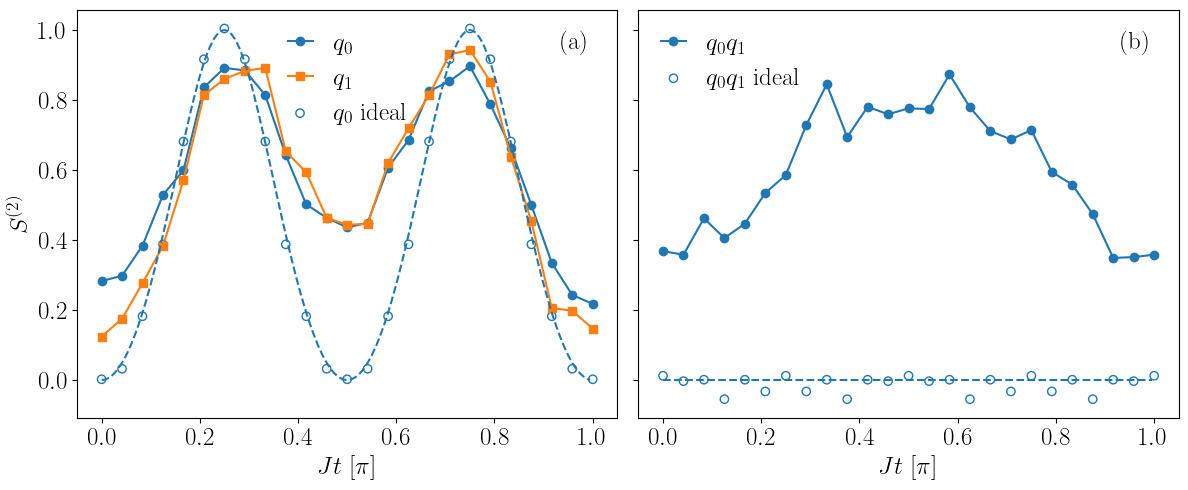

In [100]:
ts    = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: S_2 of q_0, q_1
ax1.plot(ts, -np.log2(q0angle),          label=r'$q_0$',       linestyle='-',  marker='o')
ax1.plot(ts, -np.log2(q1angle),          label=r'$q_1$',       linestyle='-',  marker='s')
ax1.plot(manyt, -np.log2(1 - 2*np.sin(manyt*np.pi)**2*np.cos(manyt*np.pi)**2), linestyle='--', color='C0')
ax1.scatter(ts, -np.log2(ideal_q0angle), label=r'$q_0$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax1.set_xlabel(r'$Jt\ [\pi]$')
ax1.set_ylabel(r'$S^{(2)}$')
ax1.legend(loc='best',frameon=False)
ax1.text(0.95, 0.95, '(a)', transform=ax1.transAxes, ha='right', va='top', fontsize=18)

# Right: S_2 of q_0 q_1
ax2.plot(ts, -np.log2(qsangle),          label=r'$q_0 q_1$',       linestyle='-', marker='o')
ax2.scatter(ts, -np.log2(ideal_qsangle), label=r'$q_0 q_1$ ideal', facecolors='none', edgecolors='C0', marker='o')
ax2.plot(manyt, np.zeros(manyt.shape),   linestyle='--', color='C0')
ax2.set_xlabel(r'$Jt\ [\pi]$')
ax2.legend(loc='upper left',frameon=False)
ax2.text(0.95, 0.95, '(b)', transform=ax2.transAxes, ha='right', va='top', fontsize=18)

fig.tight_layout()
plt.savefig('2qisingentropy.pdf')
! cp 2qisingentropy.pdf ../../qurrium_writing/


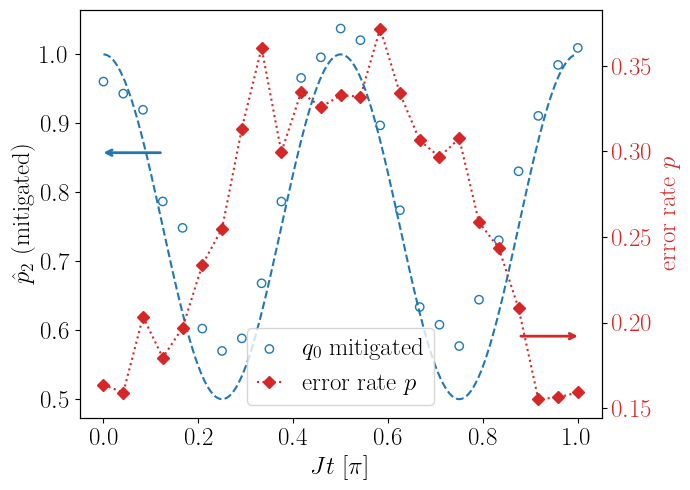

In [91]:
ts    = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200

fig, ax = plt.subplots(figsize=(7, 5))
ax_right = ax.twinx()

ax.scatter(ts, mitigated_q0angle, label=r'$q_0$ mitigated', facecolors='none', edgecolors='C0', marker='o')
#ax.scatter(ts, mitigated_q1angle, label=r'$q_1$ mitigated', facecolors='none', edgecolors='C1', marker='s')
ax.plot(manyt, 1 - 2*np.sin(manyt*np.pi)**2 * np.cos(manyt*np.pi)**2, linestyle='--', color='C0')

ax_right.plot(ts, error_rate_angle, label=r'error rate $p$', color='C3', linestyle=':', marker='D')
ax_right.set_ylabel(r'error rate $p$', color='C3')
ax_right.tick_params(axis='y', labelcolor='C3')

# Axis guide arrows: C0 pointing left (left axis), red pointing right (right axis)
ax.annotate('', xy=(0.04, 0.65), xytext=(0.16, 0.65),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='C0', lw=2))
ax_right.annotate('', xy=(0.96, 0.2), xytext=(0.84, 0.2),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='C3', lw=2))

ax.set_xlabel(r'$Jt\ [\pi]$')
ax.set_ylabel(r'$\hat{p}_2$ (mitigated)')
ax.set_yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_right.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower center')
fig.tight_layout()


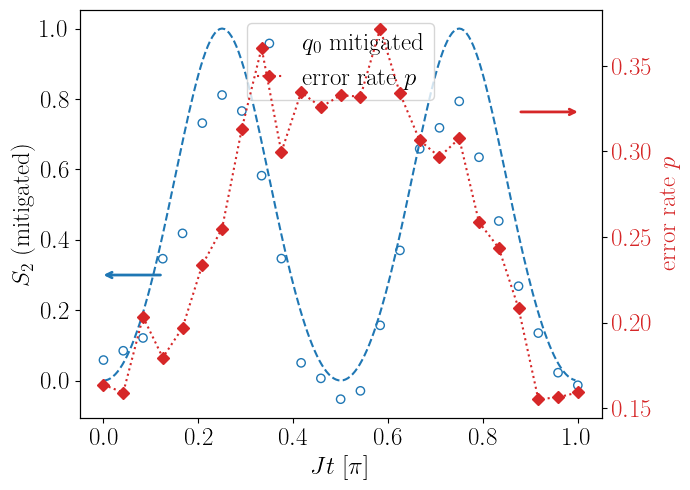

In [92]:
ts    = np.arange(0, 25) / 24
manyt = np.arange(0, 200) / 200

fig, ax = plt.subplots(figsize=(7, 5))
ax_right = ax.twinx()

ax.scatter(ts, -np.log2(mitigated_q0angle), label=r'$q_0$ mitigated', facecolors='none', edgecolors='C0', marker='o')
#ax.scatter(ts, -np.log2(mitigated_q1angle), label=r'$q_1$ mitigated', facecolors='none', edgecolors='C1', marker='s')
ax.plot(manyt, -np.log2(1 - 2*np.sin(manyt*np.pi)**2 * np.cos(manyt*np.pi)**2), linestyle='--', color='C0')

ax_right.plot(ts, error_rate_angle, label=r'error rate $p$', color='C3', linestyle=':', marker='D')
ax_right.set_ylabel(r'error rate $p$', color='C3')
ax_right.tick_params(axis='y', labelcolor='C3')

# Axis guide arrows: C0 pointing left (left axis), red pointing right (right axis)
ax.annotate('', xy=(0.04, 0.35), xytext=(0.16, 0.35),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='C0', lw=2))
ax_right.annotate('', xy=(0.96, 0.75), xytext=(0.84, 0.75),
            xycoords='axes fraction', textcoords='axes fraction',
            arrowprops=dict(arrowstyle='->', color='C3', lw=2))

ax.set_xlabel(r'$Jt\ [\pi]$')
ax.set_ylabel(r'$S_2$ (mitigated)')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_right.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper center')
fig.tight_layout()


In [14]:

basic['mean_of_rho']
ideal_basic['mean_of_rho']

array([[0.25+0.00000000e+00j, 0.25+4.31753398e-18j, 0.25-3.08395285e-18j,
        0.25+0.00000000e+00j],
       [0.25-4.31753398e-18j, 0.25+0.00000000e+00j, 0.25+0.00000000e+00j,
        0.25+2.46716228e-18j],
       [0.25+3.08395285e-18j, 0.25+0.00000000e+00j, 0.25+0.00000000e+00j,
        0.25-6.78469626e-18j],
       [0.25+0.00000000e+00j, 0.25-2.46716228e-18j, 0.25+6.78469626e-18j,
        0.25+0.00000000e+00j]])

In [106]:
3**6

729